 # Shepard Risset glissando

In [1]:
%matplotlib notebook

import numpy as np
import numpy.matlib
from scipy.io import wavfile
from matplotlib import pyplot as plt
from scipy.signal import spectrogram

<IPython.core.display.Javascript object>


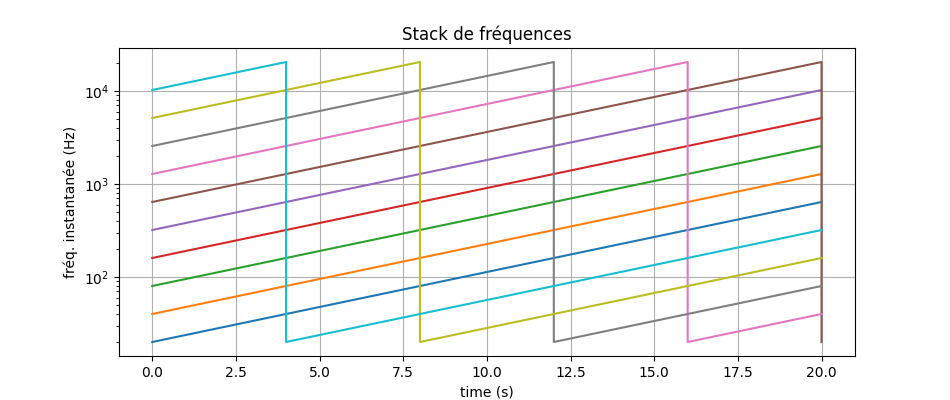

<IPython.core.display.Javascript object>


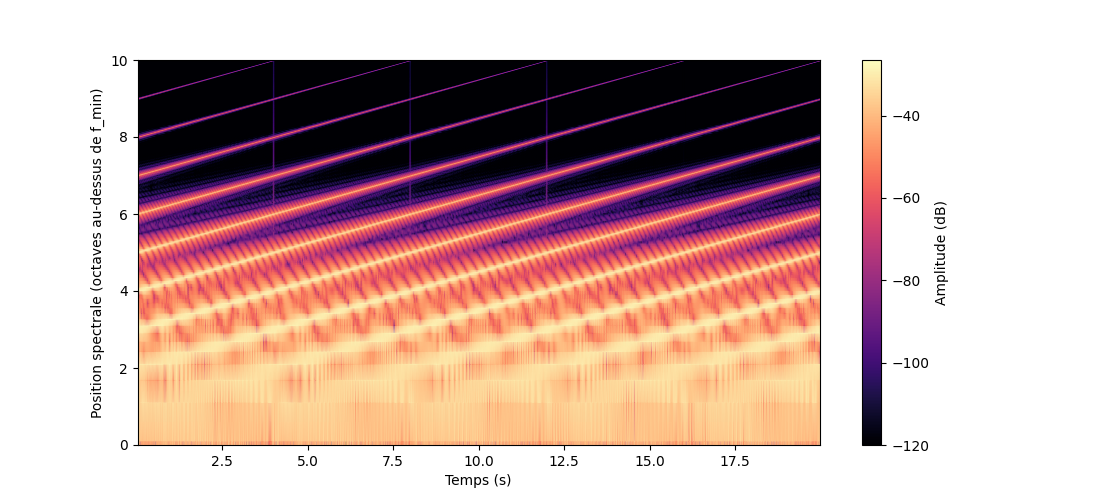

<IPython.core.display.Javascript object>


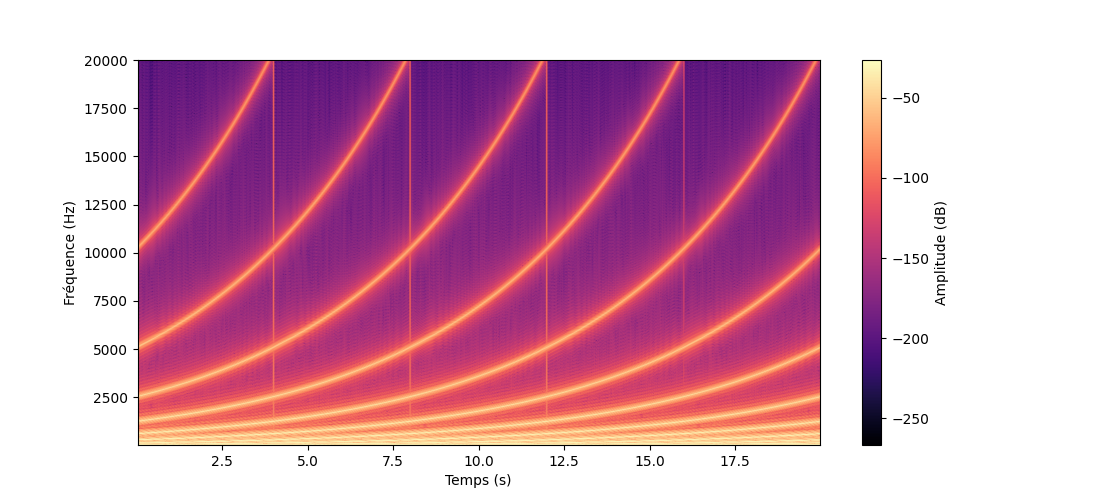

In [2]:
# Parameters
nSin = 10 # nb d'harmoniques
nOctavesParSecondes = .25 # nb d'octaves par secondes (s^-1)
nSec = 20 # durée du signal (s)
sr = 44100 # (Hz)
fMin = 20#19.6 # (Hz)

T = int(sr * nSec) # nb d'éch. temporels
t = np.linspace(0, nSec, T, endpoint=False)

# log sweep  : la fréquence de base passe de fmin à 2**nOctaves * fMin avec nOctaves = nOctavesParSecondes*nSec
nOctaves = nOctavesParSecondes*nSec
fMax = 2*fMin
fCut = 2**nSin*fMin
freqBase = np.logspace(np.log2(fMin), np.log2(2**nOctaves * fMin), len(t), base=2)

# stack freqs
freqMat = 2**(np.arange(nSin).reshape(-1, 1)) * freqBase

# circularité
logFreqMat = np.log2(freqMat/fMin)
logFreqMatCirc = np.mod(logFreqMat, nSin)
freqMatCirc = 2**logFreqMatCirc * fMin

plt.figure(figsize=(9.5,4))
plt.semilogy(t,freqMatCirc.T)
plt.grid('on')
plt.xlabel('time (s)')
plt.ylabel('fréq. instantanée (Hz)')
plt.title('Stack de fréquences')

# phase
phaseMat_tile = 2 * np.pi * np.cumsum(freqMatCirc,1) / sr
phaseMat_tile %= 2 * np.pi

# Enveloppe gaussienne en log2
center_log = 3.5 #4.5  # centre spectral (milieu des octaves)
sigma = 2 #1.4     # largeur en octaves (à ajuster selon effet souhaité)
envMat = np.exp(-0.5 * ((logFreqMatCirc - center_log) / sigma) ** 2)

# signal pondéré
sigMat = np.sin(phaseMat_tile) * envMat
sig = np.sum(sigMat, axis=0)

#sig = np.sum(sigMat, 0)

# Normalize and convert to int16
sig /= np.max(np.abs(sig))
sig_int16 = (sig * 32767).astype(np.int16)

# Save to file
wavfile.write("signal.wav", sr, sig_int16)

# Spectrogramme + log2(freq) en Y
f, t_spec, Sxx = spectrogram(sig, sr, nperseg=2048, noverlap=1024)
log2_f = np.log2(f / fMin + 1e-16)  # Échelle en octaves au-dessus de f_min

plt.figure(figsize=(11, 5))
plt.pcolormesh(t_spec, log2_f, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap = 'magma')
plt.ylim(0, nSin)  # N octaves au-dessus de f_min
plt.xlabel("Temps (s)")
plt.ylabel("Position spectrale (octaves au-dessus de f_min)")
#plt.title("Spectrogramme Shepard-Risset (échelle log₂)")
plt.colorbar(label="Amplitude (dB)")
plt.show()

# Spectrogramme
f, t_spec, Sxx = spectrogram(sig, sr, nperseg=2048, noverlap=1024)
plt.figure(figsize=(11, 5))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
plt.ylim(20, 20000)  # plage utile pour l'écoute humaine
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
#plt.title("Spectrogramme du glissando de Shepard-Risset")
plt.colorbar(label="Amplitude (dB)")
plt.show()

## Custom envelop

In [3]:
freqMat[0,:].shape

(882000,)

In [8]:
indHigh.shape

(1000,)

In [9]:
2**(nSin-1)*fMin

10240

In [7]:
freqTest = np.logspace(np.log2(fMin), np.log2(20000), 1000, base=2)

center_log = 3.5 #4.5  # centre spectral (milieu des octaves)
sigma = 2#1.8     # largeur en octaves (à ajuster selon effet souhaité)

delta = np.log2(freqTest/fMin) - center_log

env = np.exp(-0.5 * (delta / sigma) ** 2) **2

indLow = freqTest < 2*fMin
lowRamp = np.ones(freqTest.shape)
lowRamp[indLow] = np.linspace(0, 1, np.sum(indLow))

indHigh = freqTest > 2**(nSin-1)*fMin
highRamp = np.ones(freqTest.shape)
highRamp[indHigh] = np.linspace(1, 0, np.sum(indLow))

env *= lowRamp * highRamp

plt.figure(figsize=(9.5,4))
plt.semilogx(freqTest, env)
plt.grid('on')

ValueError: NumPy boolean array indexing assignment cannot assign 101 input values to the 97 output values where the mask is true

# implémentation matricielle de l'enveloppe et des rampes ?

# Ajout d'une harmonique

In [ ]:
indH = int(len(t)*7/12)
sig2 = sig+np.roll(sig, indH)

In [ ]:
# Spectrogramme
f, t_spec, Sxx = spectrogram(sig2, sr, nperseg=2048, noverlap=1024)
plt.figure(figsize=(11, 5))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
plt.ylim(20, 20000)  # plage utile pour l'écoute humaine
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
#plt.title("Spectrogramme du glissando de Shepard-Risset")
plt.colorbar(label="Amplitude (dB)")
plt.show()

In [8]:
# Normalize and convert to int16
sig2 /= np.max(np.abs(sig2))
sig2_int16 = (sig2 * 32767).astype(np.int16)

# Save to file
wavfile.write("signal3.wav", sr, sig2_int16)

NameError: name 'sig2' is not defined